<a href="https://colab.research.google.com/github/sofiiamyshelova-prog/python_for_ds_tasks/blob/main/Copy_of_HW_2_2_%D0%9F%D0%BE%D0%BB%D1%96%D0%BD%D0%BE%D0%BC%D1%96%D0%B0%D0%BB%D1%8C%D0%BD%D1%96_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA%D0%B8_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Area under ROC score on Train dataset: 0.88%


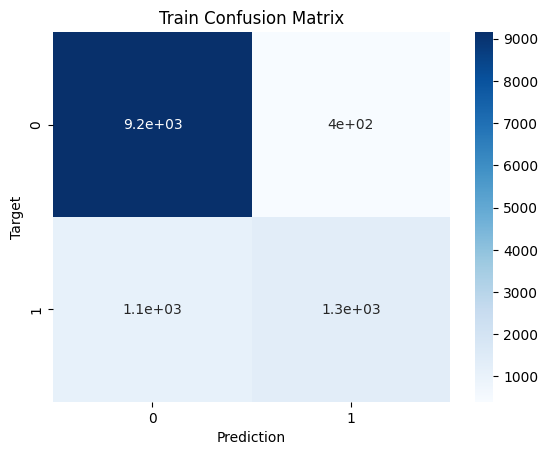

Area under ROC score on Validation dataset: 0.88%


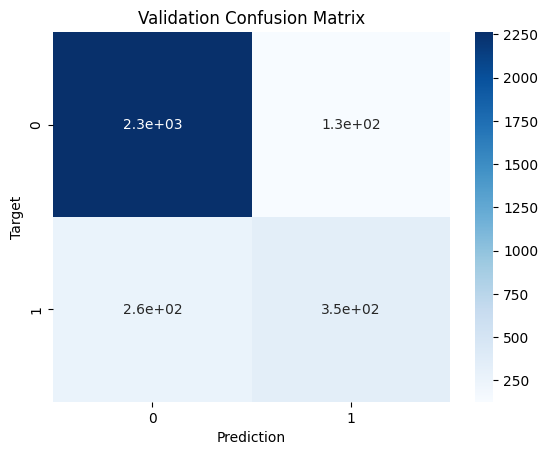

['customer_churn_pipeline.pkl']

In [4]:
import pandas as pd
raw_df = pd.read_csv('/content/drive/MyDrive/ML/data/train.csv', index_col=0)

from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(raw_df,
                                    test_size=0.2,
                                    random_state=42,
                                    stratify=raw_df["Exited"] #розбиваємо зі збереженням пропорції цільової змінної
                                    )

# Створюємо трен. і вал. набори
input_cols = ["CreditScore",
       "Geography",
       "Gender",
       "Age",
       "Tenure",
       "Balance",
       "NumOfProducts",
       "HasCrCard",
       "IsActiveMember",
       "EstimatedSalary"]
target_col = ["Exited"]
train_inputs, train_targets = train_df[input_cols],train_df[target_col]
val_inputs, val_targets = val_df[input_cols],val_df[target_col]

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include='number').columns
categorical_cols = train_inputs.select_dtypes(exclude='number').columns

# Створюємо трансформери для числових і категоріальних колонок
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

from sklearn.preprocessing import OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder())
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
from sklearn.linear_model import LogisticRegression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    probs = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, probs)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ =  confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot( model_pipeline,
                                train_inputs,
                                train_targets,
                                'Train')
val_preds = predict_and_plot(model_pipeline,
                              val_inputs,
                              val_targets,
                              'Validation')

# Зберігаємо модель для подальшого використання
import joblib
joblib.dump(model_pipeline, 'customer_churn_pipeline.pkl')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Area under ROC score on Train (Polynomial) dataset: 0.93%


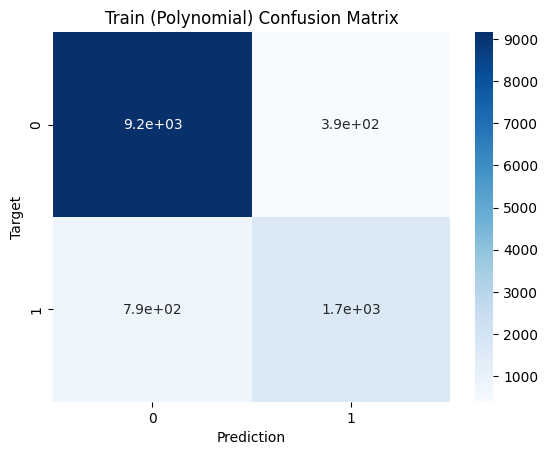

Area under ROC score on Validation (Polynomial) dataset: 0.93%


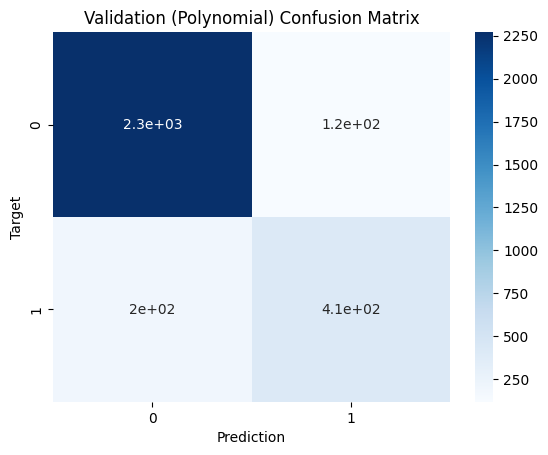

In [16]:
from sklearn.preprocessing import PolynomialFeatures

numeric_transformer_poly = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])


categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder())
])


preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


model_pipeline_poly.fit(train_inputs, train_targets)


train_preds_poly = predict_and_plot(
    model_pipeline_poly,
    train_inputs,
    train_targets,
    'Train (Polynomial)'
)

val_preds_poly = predict_and_plot(
    model_pipeline_poly,
    val_inputs,
    val_targets,
    'Validation (Polynomial)'
)

ROC 0,93 як для тренувальних, так і для валідаційних. Отже модель добре генералізує, бо однаково добре працює на даних, на яких вчилась, та на тих, на яких перевірялась.

Пере- та недонавчання не спостерігається.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Area under ROC score on Train (Polynomial) dataset: 0.95%


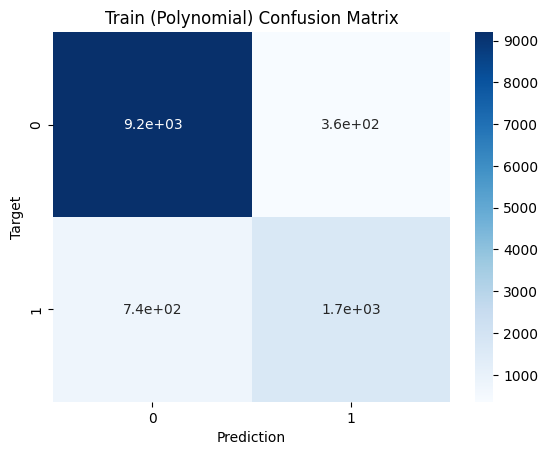

Area under ROC score on Validation (Polynomial) dataset: 0.92%


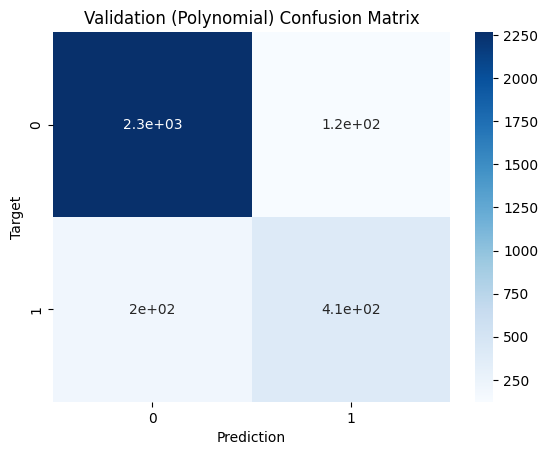

In [17]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])


categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder())
])


preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])


model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


model_pipeline_poly4.fit(train_inputs, train_targets)


train_preds_poly4 = predict_and_plot(
    model_pipeline_poly4,
    train_inputs,
    train_targets,
    'Train (Polynomial)'
)

val_preds_poly4 = predict_and_plot(
    model_pipeline_poly4,
    val_inputs,
    val_targets,
    'Validation (Polynomial)'
)

Train ROC = 0.95
Validation ROC = 0.92

Модель трохи перенавчилась, але все ще хороша. Різниця між тренувальними та валідаційними результатами невелика.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [8]:
regression_data = pd.read_csv('/content/drive/MyDrive/ML/data/regression_data.csv')

In [27]:
train_regression_data, test_regression_data = train_test_split(regression_data,
                                    test_size=0.2,
                                    random_state=42
                                    )

input_cols =['feature_1',
             'feature_2',
             'feature_3',
             'feature_4',
             'feature_5']
target_col = ['target']
train_inputs, train_targets = train_regression_data[input_cols],train_regression_data[target_col]
test_inputs, test_targets = test_regression_data[input_cols],test_regression_data[target_col]


from sklearn.linear_model import LinearRegression
def PolyRegr_pipeline(n):
  numeric_transformer_poly = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=n, include_bias=False))
    ])



  preprocessor_poly = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_poly, input_cols)
        ])


  model_pipeline_poly = Pipeline(steps=[
        ('preprocessor', preprocessor_poly),
        ('regressor', LinearRegression())
    ])

  model_pipeline_poly.fit(train_inputs, train_targets)

  return model_pipeline_poly

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
for d in range(1, 6):
    model = PolyRegr_pipeline(d)
    train_preds = model.predict(train_inputs)
    test_preds = model.predict(test_inputs)
    train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
    test_rmse = np.sqrt(mean_squared_error(test_targets, test_preds))
    train_r2 = r2_score(train_targets, train_preds)
    test_r2 = r2_score(val_targets, val_preds)


    print(f'Degree {d}')
    print(f'Train RMSE: {train_rmse:.4f}')
    print(f'Test RMSE: {test_rmse:.4f}')
    print(f'Train R²: {train_r2:.4f}')
    print(f'Test R²: {test_r2:.4f}')
    print()

Degree 1
Train RMSE: 1.0665
Test RMSE: 0.8833
Train R²: 0.9994
Test R²: 0.1954

Degree 2
Train RMSE: 1.0167
Test RMSE: 1.0149
Train R²: 0.9995
Test R²: 0.1954

Degree 3
Train RMSE: 0.7993
Test RMSE: 1.9160
Train R²: 0.9997
Test R²: 0.1954

Degree 4
Train RMSE: 0.0000
Test RMSE: 18.8027
Train R²: 1.0000
Test R²: 0.1954

Degree 5
Train RMSE: 0.0000
Test RMSE: 35.6281
Train R²: 1.0000
Test R²: 0.1954



степінь 1 - найкраще узагальнення.

степінь 2 трохи перенавчилась, але не критично.

для вищих степенів модель сильно перенавчається

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [39]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

models = [
    Ridge(),
    Lasso(),
    ElasticNet()
]


def evaluate_model(model, X_train, y_train, X_val, y_val):
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_metrics = mean_squared_error(y_train, y_train_pred)
    val_metrics = mean_squared_error(y_val, y_val_pred)


    return dict(train=train_metrics, test=val_metrics)

results = []

for model in models:
  for d in range (1,21):
        poly_features = PolynomialFeatures(degree=d)
        X_train_poly = poly_features.fit_transform(train_inputs)
        X_test_poly = poly_features.transform(test_inputs)
        model.fit(X_train_poly, train_targets)
        eval_results  = evaluate_model(model, X_train_poly, train_targets, X_test_poly, test_targets)
        results.append({
            'Model': model,
            'Degree': d,
            'Train RMSE': round(eval_results['train'], 6),
            'Test RMSE': round(eval_results['test'], 6)
        })
  results_df = pd.DataFrame(results)
  print(results_df)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.29582e-17): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.78145e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.51443e-20): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sk

      Model  Degree    Train RMSE     Test RMSE
0   Ridge()       1      1.434134  9.852530e-01
1   Ridge()       2      1.370488  1.523002e+00
2   Ridge()       3      3.271469  6.212251e+01
3   Ridge()       4      2.362350  7.341870e+02
4   Ridge()       5      1.582743  8.696539e+02
5   Ridge()       6      1.544834  9.721053e+03
6   Ridge()       7      1.528845  8.262787e+03
7   Ridge()       8      1.552604  9.812800e+04
8   Ridge()       9      1.572591  1.528622e+05
9   Ridge()      10      1.580648  9.914619e+05
10  Ridge()      11      1.587461  2.820372e+06
11  Ridge()      12      1.586543  9.548543e+06
12  Ridge()      13      1.586274  4.187334e+07
13  Ridge()      14      1.686046  8.287664e+07
14  Ridge()      15      4.087098  5.630747e+08
15  Ridge()      16  11433.193590  1.437837e+09
16  Ridge()      17    417.492528  1.117641e+08
17  Ridge()      18    513.989565  3.145373e+08
18  Ridge()      19    656.278205  1.577077e+08
19  Ridge()      20   1061.591134  8.163

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.962e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.176e+03, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.657e+03, tolerance: 2.006e

      Model  Degree    Train RMSE     Test RMSE
0   Ridge()       1      1.434134  9.852530e-01
1   Ridge()       2      1.370488  1.523002e+00
2   Ridge()       3      3.271469  6.212251e+01
3   Ridge()       4      2.362350  7.341870e+02
4   Ridge()       5      1.582743  8.696539e+02
5   Ridge()       6      1.544834  9.721053e+03
6   Ridge()       7      1.528845  8.262787e+03
7   Ridge()       8      1.552604  9.812800e+04
8   Ridge()       9      1.572591  1.528622e+05
9   Ridge()      10      1.580648  9.914619e+05
10  Ridge()      11      1.587461  2.820372e+06
11  Ridge()      12      1.586543  9.548543e+06
12  Ridge()      13      1.586274  4.187334e+07
13  Ridge()      14      1.686046  8.287664e+07
14  Ridge()      15      4.087098  5.630747e+08
15  Ridge()      16  11433.193590  1.437837e+09
16  Ridge()      17    417.492528  1.117641e+08
17  Ridge()      18    513.989565  3.145373e+08
18  Ridge()      19    656.278205  1.577077e+08
19  Ridge()      20   1061.591134  8.163

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.102e+04, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.080e+04, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.191e+04, tolerance: 2.006e

           Model  Degree    Train RMSE     Test RMSE
0        Ridge()       1      1.434134  9.852530e-01
1        Ridge()       2      1.370488  1.523002e+00
2        Ridge()       3      3.271469  6.212251e+01
3        Ridge()       4      2.362350  7.341870e+02
4        Ridge()       5      1.582743  8.696539e+02
5        Ridge()       6      1.544834  9.721053e+03
6        Ridge()       7      1.528845  8.262787e+03
7        Ridge()       8      1.552604  9.812800e+04
8        Ridge()       9      1.572591  1.528622e+05
9        Ridge()      10      1.580648  9.914619e+05
10       Ridge()      11      1.587461  2.820372e+06
11       Ridge()      12      1.586543  9.548543e+06
12       Ridge()      13      1.586274  4.187334e+07
13       Ridge()      14      1.686046  8.287664e+07
14       Ridge()      15      4.087098  5.630747e+08
15       Ridge()      16  11433.193590  1.437837e+09
16       Ridge()      17    417.492528  1.117641e+08
17       Ridge()      18    513.989565  3.1453

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.122e+04, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


На мою думку, Ridge є найкращою моделлю для цих даних, оскільки поліноміальні ознаки високих степенів створюють сильну мультиколінеарність, а L2-регуляризація ефективно обмежує величину коефіцієнтів і запобігає перенавчанню.